In [1]:
import pandas as pd
data = pd.read_excel("online_retail_II.xlsx")

In [2]:
print("First 5 Rows:")
print(data.head())

First 5 Rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [3]:
print("dataset statistics:")
print(data.describe())

dataset statistics:
            Quantity                    InvoiceDate          Price  \
count  525461.000000                         525461  525461.000000   
mean       10.337667  2010-06-28 11:37:36.845017856       4.688834   
min     -9600.000000            2009-12-01 07:45:00  -53594.360000   
25%         1.000000            2010-03-21 12:20:00       1.250000   
50%         3.000000            2010-07-06 09:51:00       2.100000   
75%        10.000000            2010-10-15 12:45:00       4.210000   
max     19152.000000            2010-12-09 20:01:00   25111.090000   
std       107.424110                            NaN     146.126914   

         Customer ID  
count  417534.000000  
mean    15360.645478  
min     12346.000000  
25%     13983.000000  
50%     15311.000000  
75%     16799.000000  
max     18287.000000  
std      1680.811316  


In [4]:
print("miissing Values:")
print(data.isnull().sum())

miissing Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [5]:
data = data.dropna()

In [6]:
print("miissing Values:")
print(data.isnull().sum())

miissing Values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64


In [7]:
data.drop_duplicates(inplace=True)

In [8]:
print("Dataset after removing duplicates:")
print(data.shape)

Dataset after removing duplicates:
(410763, 8)


In [9]:
data["Total_order_price"] = data["Quantity"] * data["Price"]

In [10]:
data = data[data["Total_order_price"] > 0]

In [11]:
print("Dataset after removing duplicates:")
print(data.shape)

Dataset after removing duplicates:
(400916, 9)


In [12]:
#remove canceled order
data = data[~data['Invoice'].astype(str).str.startswith('C')]

In [13]:
Q1 = data['Total_order_price'].quantile(0.25)
Q3 = data['Total_order_price'].quantile(0.75)

IQR = Q3 - Q1

In [14]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(lower_limit)
print(upper_limit)

-16.75
41.25


In [15]:
small_noise = data[data['Total_order_price'] < lower_limit]

In [16]:
large_outliers = data[data['Total_order_price'] > upper_limit]

In [17]:
data = data[
    (data['Total_order_price'] >= lower_limit) &
    (data['Total_order_price'] <= upper_limit)
]

In [18]:
top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

<Axes: xlabel='Description'>

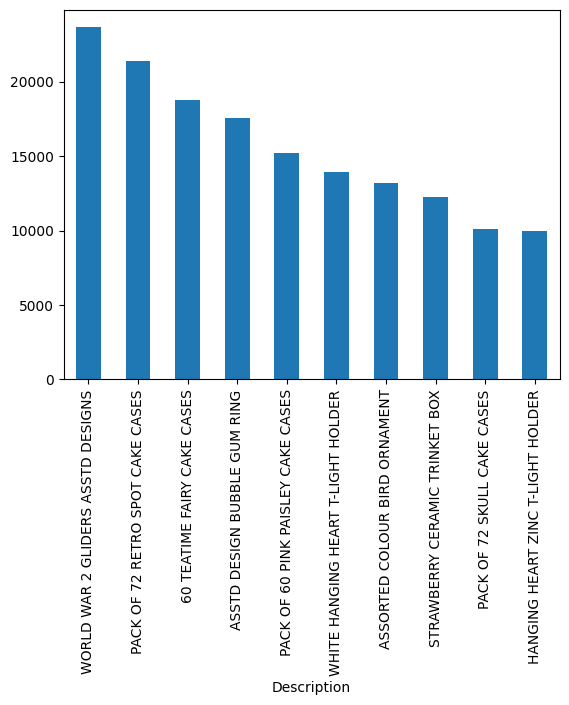

In [19]:
top_products.head(10).plot(kind='bar')

In [20]:
country_sales = data.groupby('Country')['Total_order_price'].sum()

<Axes: xlabel='Country'>

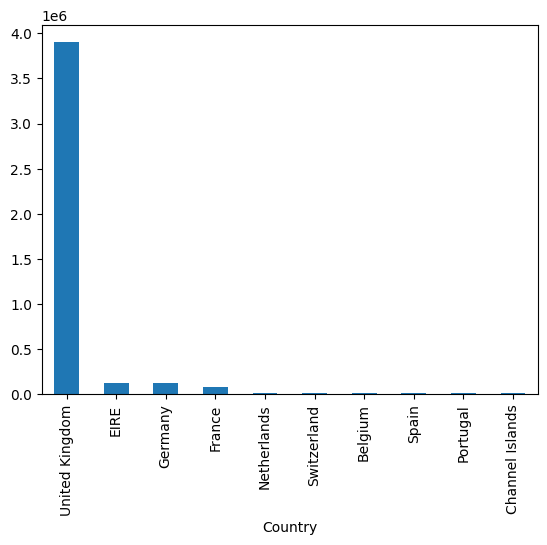

In [21]:
country_sales.sort_values(ascending=False).head(10).plot(kind='bar')

In [22]:
print("Dataset after edits")
print(data.shape)

Dataset after edits
(367073, 9)


In [25]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [26]:
data['Year'] = data['InvoiceDate'].dt.year

In [27]:
data['Month'] = data['InvoiceDate'].dt.month

In [28]:
data['Dat'] = data['InvoiceDate'].dt.day

In [29]:
data['Hour'] = data['InvoiceDate'].dt.hour

In [30]:
print("Dataset after edits")
print(data.shape)

Dataset after edits
(367073, 13)


In [31]:
data.to_excel("Fcleaned_online_retail.xlsx", index=False)